# Figure 2: `accentuation`

This notebook rebuilds the figure step by step from its script, `figures/main/fig2_accentuation.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

Figure 2 introduces feature accentuation: take a natural seed image and nudge it along a site's encoding axis so that the model's predicted firing goes down or up in graded steps. Panels a and b are hand-drawn schematics from `figures/assets` (how synthesis works, and what axis-aligned accentuation means in feature space). Panel c shows one real sweep for a V4 site of Monkey V under RN50-Robust, from suppressed on the left through the seed in the middle to driven on the right. Panel d shows the entire accentuation dataset as a 3D point cloud in a shared readout basis: encoding-axis projection vertically, two residual PCs horizontally, with the natural calibration images as a gray cloud. Panel e shows example sweeps for one site per cortical area (aIT, cIT, V3, V4, STS) and four models.

Panels c and e read the raw synthesized images from `DATA_ROOT/stimuli_control`. Panel d reads a preprocessed cache through the small helper module `fig2_data.py` next to this script; its only job is `load_cloud`, which unpickles `preprocessed_data/fig2_cloud.pkl` (built by `scripts/preprocessing/build_fig2_cloud.py`, which aligns every monkey, unit and model combination into the shared basis and pools them).

## What the script says about itself

Fig 2 - feature accentuation along encoding axes (per fig2_TEMPLATE.png).

- **(a)** stimulus-synthesis overview          (schematic - added in Keynote; blank here)
- **(b)** axis-aligned feature accentuation    (schematic - added in Keynote; blank here)
- **(c)** accentuated image sweep: suppress -> seed -> drive (venus V4, RN50-Robust, seed 4)
- **(d)** Feature Accentuation Dataset 3D cloud (residual PC1/2 x predicted firing; cache)
- **(e)** example accentuated image sweeps: aIT/cIT/V3/V4/STS x 4 models x 4 levels

C/D/E are rendered programmatically; a/b are the hand-drawn schematics (figures/assets/). Accentuated images come from DATA_ROOT/stimuli_control; the cloud from fig2_data.load_cloud() (preprocessed_data/fig2_cloud.pkl, built by scripts/preprocessing/build_fig2_cloud.py).

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`C_MONKEY`, `C_UNIT`, `C_MODEL`, `C_SEED` choose the single sweep in panel c, and `C_SUPPRESS` and `C_DRIVE` are the level indices shown on either side of the seed (four each). For panel e, `E_MODELS` lists the four models (rows), `LEVEL_PICK` the four level indices (columns), and `GRID_SITES` the five sites with their grid position, region label and seed. `THUMB`, `BORDER` and `GAP` are pixel sizes for the pasted mosaics, `CMAP` is the red-blue border colormap, and `CYAN` is the encoding-axis color shared with Figure 3. Swapping entries in `GRID_SITES` or `E_MODELS` is the easiest way to show other sites or models.

In [2]:
import os

import numpy as np

from PIL import Image, ImageFile, ImageEnhance

ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors

import matplotlib.patheffects as pe

from matplotlib.gridspec import GridSpec

from pnc import paths

from pnc.manifest import MAIN_FIGURES

from pnc.utils import (apply_figure_style, FONT_FAMILY, FIG_FACECOLOR, save_fig,
                       DATA_ROOT, STIMULI_PATH, MONKEY_DIRS, ACCENT_DATE_PREFIXES,
                       MODEL_SHORT_NAMES, MODEL_COLORS, MONKEY_COLORS, parse_stimulus_name)

from figures.main import fig2_data as D

apply_figure_style()

MODEL_SHORT_NAMES = dict(MODEL_SHORT_NAMES)

MODEL_SHORT_NAMES['AlexNet_training_seed_01'] = 'Untrained'

# ── what to show ────────────────────────────────────────────────────────
SEED_FILENAMES = ['shared0575_nsd43157.png', 'shared0850_nsd61798.png', 'shared0968_nsd70194.png',
                  'shared0241_nsd20065.png', 'shared0160_nsd13231.png', 'shared0070_nsd07008.png',
                  'shared0055_nsd05879.png', 'shared0668_nsd48623.png', 'shared0488_nsd36979.png',
                  'shared0940_nsd68312.png']

# c: single sweep
C_MONKEY, C_UNIT, C_MODEL, C_SEED = 'venus', 151, 'resnet50_robust', 4

C_SUPPRESS, C_DRIVE = [0, 1, 2, 3], [5, 6, 7, 8]   # 4 + seed + 4 = 9

SEED_YELLOW = (250, 221, 112)                      # light yellow (matches template seed border)

SEED_PNG = str(paths.ASSETS / 'seed.png')          # sweep seed image

# e: 2x3 region grid (cell (0,0) is the cloud d); each = 4 models x 4 levels
E_MODELS = ['resnet50', 'dinov2_vitb14_reg', 'resnet50_robust', 'clipag_vitb32']

LEVEL_PICK = [0, 1, 7, 10]

GRID_SITES = [(0, 1, 'red', 19, 'aIT', 1), (0, 2, 'paul', 8, 'cIT', 2),
              (1, 0, 'venus', 331, 'V3', 4), (1, 1, 'venus', 151, 'V4', 8),
              (1, 2, 'three0', 120, 'STS', 5)]

THUMB, BORDER, GAP = 150, 6, 4

SEED_BORDER = (140, 140, 140)

CMAP = plt.colormaps['RdBu_r']

CYAN = '#00C39A'                                   # encoding-axis teal (matches figure 3)

FS_PANEL, FS_TITLE, FS_REGION, FS_MODEL, FS_ANNOT = 28, 17, 18, 10, 13

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

The helpers come in three groups: image utilities that locate and load accentuated stimuli (`_accent_dir`, `_floor`, `load_sweep`, `_thumb`, `_bordered`), the two mosaic builders for panels c and e, and the drawing helpers for panel d (`draw_cloud` and the `_pc_widget` basis glyph).

### `_accent_dir(monkey, model)`

── image helpers ────────────────────────────────────────────────────────

Builds the path to one monkey and model's accentuation directory from the date-prefix and monkey-directory tables in `pnc.utils`.

In [3]:
# ── image helpers ────────────────────────────────────────────────────────
def _accent_dir(monkey, model):
    return os.path.join(DATA_ROOT, 'stimuli_control',
                        f'{ACCENT_DATE_PREFIXES[monkey]}_{MONKEY_DIRS[monkey]}_{model}_accentuation')

### `_boost(img)`

In [4]:
def _boost(img):
    return ImageEnhance.Brightness(ImageEnhance.Color(img).enhance(1.32)).enhance(1.06)

### `_floor(monkey, unit)`

Returns the site's firing floor in z units from the loader; achieved scores are clamped at this floor so border colors never encode a predicted rate below zero spikes.

In [5]:
def _floor(monkey, unit):
    from pnc.preproc import loader as L
    return L.firing_floor(monkey, int(unit))

### `load_sweep(monkey, model, unit, seed)`

(target, clamped score, path) per level, sorted low->high target.

Lists the accentuated images for one monkey, model, unit and seed, parses the target level and achieved score from each filename, skips hyperparameter-tuning files, clamps the score at the floor, and returns the sweep sorted from lowest to highest target.

In [6]:
def load_sweep(monkey, model, unit, seed):
    """(target, clamped score, path) per level, sorted low->high target."""
    d = _accent_dir(monkey, model); pre = f'{model}_RidgeCV_unit_{unit}_img_{seed}_'
    fl = _floor(monkey, unit); items = []
    for fn in sorted(os.listdir(d)):
        if not fn.startswith(pre) or 'hp_tuning' in fn:
            continue
        p = parse_stimulus_name(fn)
        if p is None:
            continue
        items.append((p['target'], max(p['score'], fl), os.path.join(d, fn)))
    items.sort(key=lambda t: t[0])
    return items

### `_thumb(path)`

In [7]:
def _thumb(path):
    return _boost(Image.open(path).convert('RGB').resize((THUMB, THUMB), Image.LANCZOS))

### `_bordered(inner, rgb)`

In [8]:
def _bordered(inner, rgb):
    cell = Image.new('RGB', (THUMB, THUMB), rgb)
    cell.paste(inner.resize((THUMB - 2 * BORDER, THUMB - 2 * BORDER), Image.LANCZOS), (BORDER, BORDER))
    return cell

### `build_sweep_strip()`

── panel c: single sweep strip ─────────────────────────────────────────

Assembles panel c as a single PIL strip: the chosen suppress levels, the seed image (`figures/assets/seed.png`) with a yellow border, then the chosen drive levels. Border colors are normalized over the achieved scores of the shown levels only, so the coldest and warmest borders are the extremes of this strip. Returns the strip and the number of suppress and drive levels actually found.

In [9]:
# ── panel c: single sweep strip ─────────────────────────────────────────
def build_sweep_strip():
    sweep = load_sweep(C_MONKEY, C_MODEL, C_UNIT, C_SEED)
    n = len(sweep)
    supp = [i for i in C_SUPPRESS if i < n]; drive = [i for i in C_DRIVE if i < n]
    seed_img = _boost(Image.open(SEED_PNG).convert('RGB').resize((THUMB, THUMB), Image.LANCZOS))
    imgs = ([_thumb(sweep[i][2]) for i in supp] + [seed_img]
            + [_thumb(sweep[i][2]) for i in drive])
    scores = [sweep[i][1] for i in supp] + [None] + [sweep[i][1] for i in drive]   # seed -> yellow
    sd = [s for s in scores if s is not None]
    norm = mcolors.Normalize(vmin=min(sd), vmax=max(sd))
    W = len(imgs) * (THUMB + GAP) - GAP
    canvas = Image.new('RGB', (W, THUMB), (255, 255, 255))
    for ci, (img, sc) in enumerate(zip(imgs, scores)):
        rgb = SEED_YELLOW if sc is None else tuple(int(v * 255) for v in CMAP(norm(sc))[:3])
        canvas.paste(_bordered(img, rgb), (ci * (THUMB + GAP), 0))
    return canvas, len(supp), len(drive)

### `build_mosaic(monkey, unit, seed)`

── panel e: per-region mosaic (4 models x 4 levels) ────────────────────

Builds one panel-e mosaic for a site: rows are the four `E_MODELS`, columns the four `LEVEL_PICK` levels. Border colors are normalized over all sixteen shown scores, so colors are comparable within a mosaic but not across mosaics.

In [10]:
# ── panel e: per-region mosaic (4 models x 4 levels) ────────────────────
def build_mosaic(monkey, unit, seed):
    sweeps = {m: load_sweep(monkey, m, unit, seed) for m in E_MODELS}
    scores = [sweeps[m][i][1] for m in E_MODELS for i in LEVEL_PICK]
    norm = mcolors.Normalize(vmin=min(scores), vmax=max(scores))
    W = len(LEVEL_PICK) * THUMB + (len(LEVEL_PICK) - 1) * GAP
    H = len(E_MODELS) * THUMB + (len(E_MODELS) - 1) * GAP
    canvas = Image.new('RGB', (W, H), (255, 255, 255))
    for ri, m in enumerate(E_MODELS):
        for ci, idx in enumerate(LEVEL_PICK):
            _, sc, path = sweeps[m][idx]
            rgb = tuple(int(v * 255) for v in CMAP(norm(sc))[:3])
            canvas.paste(_bordered(_thumb(path), rgb), (ci * (THUMB + GAP), ri * (THUMB + GAP)))
    return canvas

### `_row_y(bb, i, n)`

In [11]:
def _row_y(bb, i, n):
    return bb.y1 - (i + 0.5) / n * (bb.y1 - bb.y0)

### `_pc_widget(fig, x0, y0, side_in=0.66)`

3-axis readout-basis glyph (same as figure 3): encoding proj (up), residual PC2 (diagonal), residual PC1 (right). Square inset at (x0, y0).

Draws the three-arrow readout-basis glyph (encoding projection up, residual PC2 diagonal, residual PC1 right) in a physically square inset, sized in inches so the arrows are not distorted by the panel's aspect ratio.

In [12]:
def _pc_widget(fig, x0, y0, side_in=0.66):
    """3-axis readout-basis glyph (same as figure 3): encoding proj (up),
    residual PC2 (diagonal), residual PC1 (right). Square inset at (x0, y0)."""
    fw, fh = fig.get_size_inches()
    iax = fig.add_axes([x0, y0, side_in / fw, side_in / fh], zorder=60)
    iax.set_xlim(-0.15, 1.3); iax.set_ylim(-0.2, 1.25); iax.axis('off')
    specs = [((0.0, 1.0), 'encoding\nproj.', 'right', 'top', (-0.08, 0.12)),
             ((0.72, 0.72), 'residual\nPC2', 'left', 'center', (0.10, 0.04)),
             ((1.0, 0.0), 'residual\nPC1', 'center', 'top', (0.05, -0.14))]
    for (x, y), lbl, ha, va, (lx, ly) in specs:
        iax.annotate('', xy=(x, y), xytext=(0.0, 0.0),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1.5,
                                     shrinkA=0, shrinkB=0), zorder=61)
        iax.text(x + lx, y + ly, lbl, fontsize=10, fontfamily=FONT_FAMILY, color='black',
                 ha=ha, va=va, linespacing=1.0, zorder=61, clip_on=False)

### `draw_cloud(ax)`

── panel d: 3D cloud ────────────────────────────────────────────────────

Draws panel d on a 3D axes. The natural-image cloud is shifted so its centroid coincides with the centroid of the accentuated points, then plotted in gray; the accentuated points are colored by predicted level with a diverging norm centered at zero. Axis limits are set from the 0.5 to 99.5 percentiles of all points with a small margin, the box is stretched vertically, the view is nearly edge-on, and all axis furniture is hidden. Returns the colormap and norm so the assembly can draw a matching colorbar.

In [13]:
# ── panel d: 3D cloud ────────────────────────────────────────────────────
def draw_cloud(ax):
    C = D.load_cloud()
    enc = C['enc']; trajs = C['trajectories']; tlev = C['traj_levels']
    cmap = plt.colormaps['coolwarm']
    all_lv = np.concatenate(tlev)
    norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=all_lv.min(), vmax=all_lv.max())
    acc = np.vstack(trajs)
    enc_sh = enc + (acc.mean(0) - enc.mean(0))
    ax.computed_zorder = False
    # plain point cloud only (no trajectory lines, no highlighted markers)
    ax.scatter(enc_sh[:, 0], enc_sh[:, 1], enc_sh[:, 2], c='#999999', s=3, alpha=0.5,
               edgecolors='none', depthshade=True, rasterized=True, zorder=1)
    ax.scatter(acc[:, 0], acc[:, 1], acc[:, 2], c=all_lv, cmap=cmap, norm=norm, s=3, alpha=0.55,
               edgecolors='none', depthshade=True, rasterized=True, zorder=2)
    allp = np.concatenate([enc_sh, acc], 0)
    for i, setter in enumerate((ax.set_xlim, ax.set_ylim, ax.set_zlim)):
        lo, hi = np.percentile(allp[:, i], 0.5), np.percentile(allp[:, i], 99.5); m = (hi - lo) * 0.08
        setter(lo - m, hi + m)
    ax.set_box_aspect([1, 1, 1.7]); ax.view_init(elev=5, azim=-60)
    ax.set_axis_off()
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.fill = False; pane.set_edgecolor('none')
    ax.grid(False)
    return cmap, norm

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

The figure is a tall canvas whose bottom half is a 2 by 3 grid (`de`): cell (0, 0) holds the 3D cloud and the other five cells hold the region mosaics. The top half is placed by hand: the two schematics as free axes (b overlaps a and sits in front), and the wide sweep strip below them. All annotation is done after a canvas draw so it can read the actual axes positions.

In [14]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)

**Step 1**

Creates the figure and grid, places the two schematic images with their titles, builds and displays the panel-c strip, draws the cloud into the top-left grid cell, and fills the remaining cells with one `build_mosaic` call per entry in `GRID_SITES`.

In [15]:
fig = plt.figure(figsize=(15.0, 16.8), facecolor=FIG_FACECOLOR)   # 25 : 28 aspect
DE_TOP = 0.566                       # bigger bottom half; cells ~square so mosaics fill (no side gaps)
de = GridSpec(2, 3, figure=fig, left=0.045, right=0.985, top=DE_TOP, bottom=0.002,
              wspace=0.056, hspace=0.095)   # ~3mm gaps between mosaics (sides); rows fit region labels
schem_dir = str(paths.ASSETS)
# b (front, right) overlaps a (behind, left); c (wide sweep) sits below them with breathing room
ax_a = fig.add_axes([0.015, 0.754, 0.515, 0.20], zorder=2)
ax_b = fig.add_axes([0.49, 0.749, 0.46, 0.205], zorder=5)
ax_c = fig.add_axes([0.06, 0.643, 0.88, 0.085], zorder=3)
for ax, fn in [(ax_a, 'schematic_2a.png'), (ax_b, 'schematic_2b.png')]:
    ax.imshow(np.asarray(Image.open(os.path.join(schem_dir, fn)).convert('RGB')))
    ax.set_axis_off()
ax_a.set_title('Stimulus synthesis overview', fontsize=FS_TITLE, fontfamily=FONT_FAMILY,
               fontweight='bold', loc='center', pad=12)
ax_b.set_title('Axis-aligned feature accentuation', fontsize=FS_TITLE, fontfamily=FONT_FAMILY,
               fontweight='bold', loc='center', pad=12)

# c - sweep strip
strip, n_supp, n_drive = build_sweep_strip()
ax_c.imshow(np.asarray(strip)); ax_c.set_axis_off(); ax_c.set_anchor('N')

# d + e grid
ax_cloud = fig.add_subplot(de[0, 0], projection='3d')
cmap_d, norm_d = draw_cloud(ax_cloud)
e_axes = []
for (r, c, mk, u, region, seed) in GRID_SITES:
    ax = fig.add_subplot(de[r, c])
    ax.imshow(np.asarray(build_mosaic(mk, u, seed))); ax.set_axis_off(); ax.set_anchor('N')
    e_axes.append((region, mk, ax))

**Step 2**

Draws the canvas to fix positions, then adds every label: the "decreased / seed / increased firing" captions under the strip, the panel-d title with the dataset size, its colorbar, the vertical cyan "encoding axis" text and arrow, the "natural image distribution" tag, the basis glyph, the panel-e title, region labels in each monkey's color, model labels in each model's color rotated beside the rows, and the panel letters.

In [16]:
fig.canvas.draw()

# ---- c labels (below the strip) ----
bb_c = ax_c.get_position()
ax_c.set_title('Accentuated image sweep', fontsize=FS_TITLE, fontfamily=FONT_FAMILY,
               fontweight='bold', pad=4, loc='left')
yb = bb_c.y0 - 0.006
fig.text(bb_c.x0 + 0.06, yb, 'prediction: decreased firing', fontsize=FS_ANNOT, color='#3B6FB0',
         fontfamily=FONT_FAMILY, ha='left', va='top')
fig.text((bb_c.x0 + bb_c.x1) / 2, yb, 'seed image', fontsize=FS_ANNOT, color='#555',
         fontfamily=FONT_FAMILY, fontweight='bold', ha='center', va='top')
fig.text(bb_c.x1 - 0.06, yb, 'prediction: increased firing', fontsize=FS_ANNOT, color='#C0392B',
         fontfamily=FONT_FAMILY, ha='right', va='top')

# ---- d annotations (title/subtitle in the band above the cloud cell) ----
bb_d = ax_cloud.get_position()
de_top = DE_TOP
cx_d = (bb_d.x0 + bb_d.x1) / 2
fig.text(cx_d, de_top + 0.026, 'Feature Accentuation Dataset',
         fontsize=FS_TITLE, fontfamily=FONT_FAMILY, fontweight='bold', va='bottom', ha='center')
fig.text(cx_d, de_top + 0.009, '(n = 2,500 image sweeps; 27,500 stimuli)',
         fontsize=FS_ANNOT - 1, fontfamily=FONT_FAMILY, color='#666', va='bottom', ha='center')
dh = bb_d.y1 - bb_d.y0
cbx = bb_d.x0 + 0.006
cax = fig.add_axes([cbx, bb_d.y0 + 0.30 * dh, 0.010, 0.34 * dh])
plt.colorbar(plt.cm.ScalarMappable(norm=norm_d, cmap=cmap_d), cax=cax); cax.set_yticks([])
fig.text(cbx + 0.005, bb_d.y0 + 0.66 * dh, 'predicted\nfiring rate', fontsize=FS_ANNOT,
         color='#666', fontfamily=FONT_FAMILY, ha='center', va='bottom')
# encoding axis: cyan text (vertical, reads up) + a separate long cyan arrow to its right
fig.text(bb_d.x0 + 0.050, bb_d.y0 + 0.52 * dh, 'encoding axis', fontsize=FS_ANNOT + 2,
         color=CYAN, fontfamily=FONT_FAMILY, fontweight='bold', rotation=90, ha='center', va='center')
eax = fig.add_axes([bb_d.x0 + 0.060, bb_d.y0 + 0.37 * dh, 0.03, 0.32 * dh]); eax.axis('off')
eax.annotate('', xy=(0.5, 0.98), xytext=(0.5, 0.02), xycoords='axes fraction',
             arrowprops=dict(arrowstyle='-|>', color=CYAN, lw=2.6, mutation_scale=16))
# natural-image distribution: near the gray cluster (mid-right)
fig.text(bb_d.x1 - 0.015, bb_d.y0 + 0.42 * dh, 'natural image\ndistribution', fontsize=FS_ANNOT - 1.5,
         color='#888', fontfamily=FONT_FAMILY, ha='right', va='center')
# 3-axis readout-basis legend (same as figure 3), bottom-left
_pc_widget(fig, bb_d.x0 + 0.038, bb_d.y0 + 0.004)

# ---- e labels ----
bb_ait = e_axes[0][2].get_position()
fig.text((bb_ait.x0 + e_axes[1][2].get_position().x1) / 2, DE_TOP + 0.026,
         'Example accentuated image sweeps', fontsize=FS_TITLE, fontfamily=FONT_FAMILY,
         fontweight='bold', ha='center', va='bottom')
for region, mk, ax in e_axes:
    bb = ax.get_position()
    fig.text((bb.x0 + bb.x1) / 2, bb.y1 + 0.004, region, fontsize=FS_REGION, fontfamily=FONT_FAMILY,
             fontweight='black', color=MONKEY_COLORS[mk], ha='center', va='bottom',
             path_effects=[pe.withStroke(linewidth=0.8, foreground=MONKEY_COLORS[mk])])
    for ri, m in enumerate(E_MODELS):
        fig.text(bb.x0 - 0.006, _row_y(bb, ri, len(E_MODELS)), MODEL_SHORT_NAMES[m],
                 fontsize=FS_MODEL, fontfamily=FONT_FAMILY, fontweight='black',
                 color=MODEL_COLORS[m], rotation=90, ha='center', va='center',
                 path_effects=[pe.withStroke(linewidth=0.7, foreground=MODEL_COLORS[m])])

# ---- panel letters ----
pa, pb = ax_a.get_position(), ax_b.get_position()
fig.text(max(0.004, pa.x0 - 0.030), pa.y1 + 0.018, 'a', fontsize=FS_PANEL,
         fontfamily=FONT_FAMILY, fontweight='bold', va='bottom', ha='left')
fig.text(pa.x1 + 0.006, pb.y1 + 0.018, 'b', fontsize=FS_PANEL,   # right of a (a covers b's left)
         fontfamily=FONT_FAMILY, fontweight='bold', va='bottom', ha='left')
fig.text(0.004, de_top + 0.026, 'd', fontsize=FS_PANEL, fontfamily=FONT_FAMILY,
         fontweight='bold', va='bottom', ha='left')
fig.text(0.004, bb_c.y1 + 0.003, 'c', fontsize=FS_PANEL, fontfamily=FONT_FAMILY, fontweight='bold',
         va='bottom', ha='left')
fig.text(max(0.004, bb_ait.x0 - 0.030), DE_TOP + 0.026, 'e', fontsize=FS_PANEL,
         fontfamily=FONT_FAMILY, fontweight='bold', va='bottom', ha='left')

Text(0.3342410501193317, 0.592, 'e')

**Step 3**

Saves the figure through `save_fig`, closes it, and prints how many suppress and drive levels made it into the strip.

In [17]:
path = save_fig(fig, os.path.join(out_dir, MAIN_FIGURES[2]))
plt.close(fig)
print(f'Saved -> {path}  (c: {n_supp} suppress + seed + {n_drive} drive)')
png = path

Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/accentuation.png  (c: 4 suppress + seed + 4 drive)


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `accentuation.png` in the output directory).

Follow the border colors: within every strip and mosaic they run from blue (suppressed) through the yellow seed to red (driven). In panel d the colored accentuated points extend well beyond the gray natural cloud along the vertical encoding axis, which is the whole point of the design.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/accentuation.png


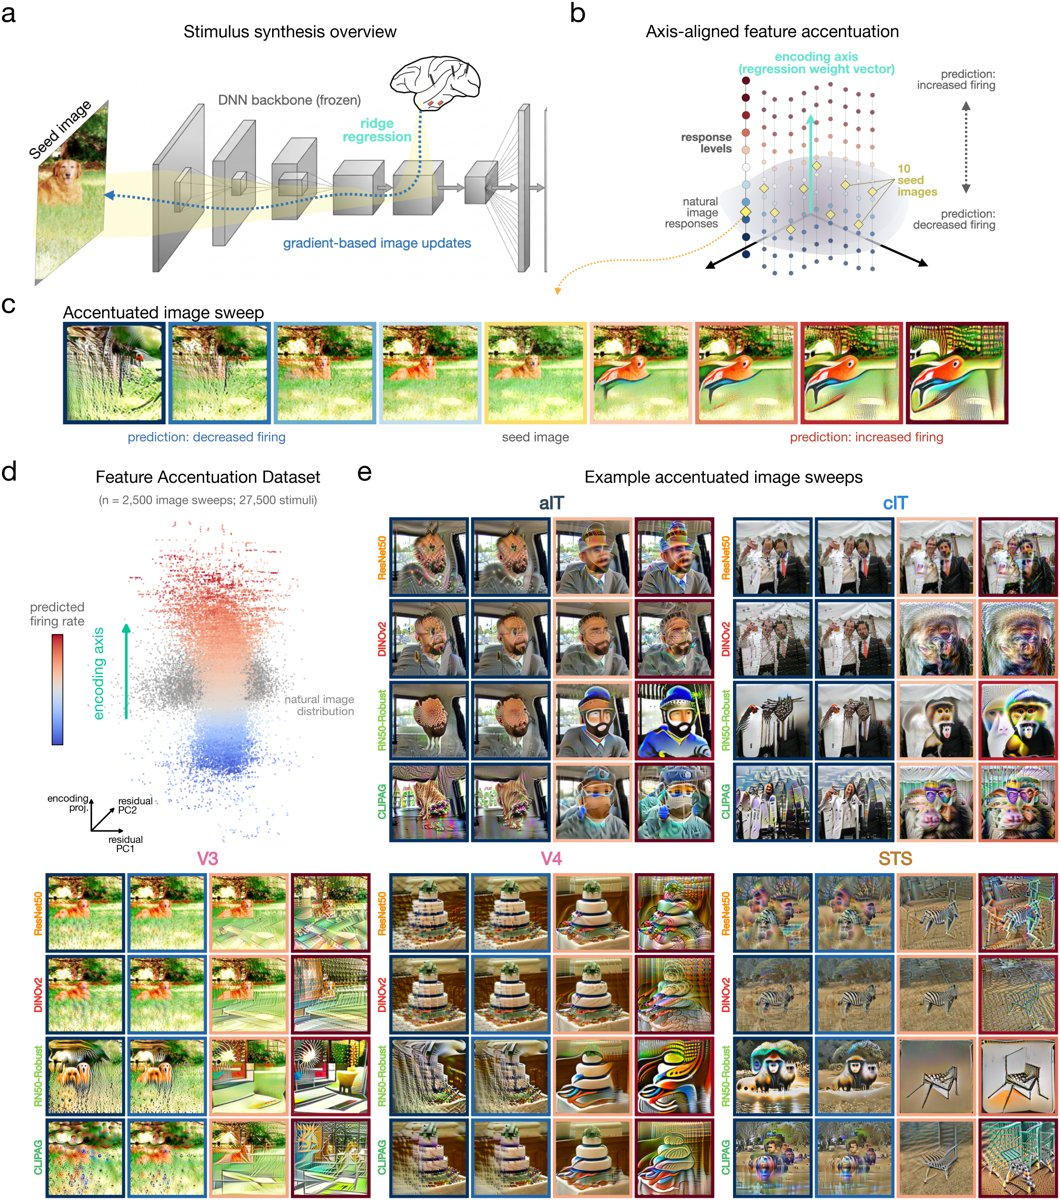

In [18]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Figure 2. Feature accentuation along DNN encoding axes.** (A) For each neural site and DNN model, a ridge regression weight vector (an "encoding axis") was fit from layer activation PCs to recorded responses using the calibration stimuli. Gradient-based image updates were then propagated through the model to modify a seed image toward a target predicted response level along the encoding axis. (B) Schematic of axis-aligned feature accentuation in DNN layer feature space. The gray cloud indicates the distribution of natural image responses, and dots are colored by predicted firing rate. The cyan arrow indicates the encoding axis, and the two other axes reflect two orthogonal latent dimensions in the source layer feature space. Yellow diamonds indicate the embeddings of 10 seed images, each accentuated to 11 target response levels spanning below and above the natural-image response range. (C) Subset of an example accentuated image sweep for one seed image, model, and neural site. The original seed image is shown at center, with progressively decreased predicted firing to the left and increased predicted firing to the right. Border colors indicate predicted response levels (blue = low, red = high). (D) The complete accentuation design ($n = 2500$ image sweeps, $27{,}500$ seed $\times$ site $\times$ level cells; the $27{,}720$ synthesized stimuli include re-synthesized Monkey L variants that are merged per cell, see Methods) visualized in the three-dimensional principal component space of an example encoder (ResNet50). The vertical dimension reflects projection onto the encoding axis, and the two horizontal dimensions reflect the first two principal components of residual variance. The gray region indicates the natural-image response range from the calibration set. (E) Example accentuated image sweeps for one representative site per cortical area, shown for four DNN models. Rows correspond to models accentuating the same seed image for the same neural site, and columns show four predicted response levels from low to high firing rate.